**Sam Polyakov and Teagan Turner**

Spring 2026

CS 443: Bio-inspired Machine Learning

# Project 3: Word Embeddings and Self-Organizing Maps (SOMs)

#### Week 1: Natural language processing and word embeddings

You will train a Skip-gram (word2vec) neural network commonly used in the field of natural language processing (NLP) on text from IMDb user movie reviews. The goal of the network is to predict **context words** (the words surrounding each word in a sentence). After implementing and training the network, you will extract the weights to obtain $H$ dimensional **word embedding** vectors for English words that appeared in the movie reviews. You will continue to leverage TensorFlow to implement and train the Skip-gram neural network on the IMDd dataset.

In the second part of the project (`word_cloud.ipynb`), you will implement a self-organizing map (SOM), a competitive bio-inspired neural network that performs dimensionality reduction on its inputs. This network will learn the nonlinear structure of the IMDb word embeddings (in $H$ dimensions) (*unsupervised learning*) and allow you to visualize the words in a 2D space. Remarkably, words with similar meanings should appear nearby each other, even though the network knows nothing about the definitions of the words!

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf

plt.style.use(['seaborn-v0_8-colorblind', 'seaborn-v0_8-darkgrid'])
plt.show()
plt.rcParams.update({'font.size': 18})

np.set_printoptions(suppress=True, precision=7)

# Automatically reload external modules
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Task 1: Preprocess IMDb review dataset

Let's begin by preprocessing the IMDb movie reviews so that we are able to train a neural network on numerical representations of the text data. The class `WordLevelDataset` in `text_dataset_word.py` is the class that stores the dataset and performs the preprocessing operations.

In [10]:
from text_dataset_word import WordLevelDataset

### 1a. Write the `WordLevelDataset` constructor and get methods

This includes:
1. constructor
2. `get_reviews`
3. `get_filepath`
4. `get_corpus`
5. `get_context_words`
6. `get_target_words`
7. `get_word2ind_map`
8. `get_ind2word_map`
9. `get_vocab`

In [11]:
imdb_ds = WordLevelDataset()
print(f'The dataset filepath to load is: {imdb_ds.get_filepath()} and should be data/imdb_train.csv')

The dataset filepath to load is: data/imdb_train.csv and should be data/imdb_train.csv


### 1b. Load in IMDb review data

Implement the `load(N_reviews)` method that should load in the movie review text data from `imdb_train.csv`. The goal is to get a Python list of length 45,000 (there are 45,000 reviews in the training set), where element $i$ is a single string representing the $i^{th}$ review. You're welcome to do this however you like. I suggest using pandas.

In [12]:
reviews = imdb_ds.load(N_reviews=-1)
print(f'{len(reviews)} reviews were loaded. 45000 should have been loaded.')

45000 reviews were loaded. 45000 should have been loaded.


In the cell below, print out the first 10 reviews  (*non-shuffled*). Make sure they match what you see in the raw CSV file.

In [13]:
imdb_ds = WordLevelDataset()
first_10_reviews = imdb_ds.load(10)

for i, review in enumerate(first_10_reviews):
    print(f"Review {i}:")
    print(review)
    print()


Review 0:
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due 

### 1c. Extract a subset of the reviews

Call `load` again in the cell below, but this time select the first 10 reviews for development and assign it to the variable `reviews_dev`.

Print out the reviews again and make sure they match what you obtained above.

In [14]:
reviews_dev = imdb_ds.load(10)

for i, review in enumerate(reviews_dev):
    print(f"Review {i}:")
    print(review)
    print()


Review 0:
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due 

### 1d. Create a corpus

In NLP, we usually define a **corpus**, which is the set of documents from which we're interested in learning. For the IMDb dataset and Skip-gram network, this represents a list of sentences across all the reviews (*from the subset that you selected*).

The problem is that the reviews are chunked by review, not sentence.
- In `text_dataset_word.py` implement the `make_corpus` function to build a Python list where elements are sentences, not reviews.
- In the cell below, call `make_corpus` on the 10 reviews, assign the resulting list of sentences as a variable called `corpus` for the below test code to work.

In [15]:
corpus = imdb_ds.make_corpus(reviews_dev)

print(f'There are {len(corpus)} sentences in the corpus. There should be 88.')

There are 88 sentences in the corpus. There should be 88.


### 1e. Identify unique words and make the vocabulary

Now that you have a corpus of sentences, let's create the **vocabulary**, defined as the unique words in the corpus (across all the sentences).
1. In `text_dataset_word.py` implement the `make_vocabulary` function that returns a list of unique words in the corpus.
2. Call this function below on your corpus. Define `vocab_sz` as the vocab size.

In [16]:
vocab = imdb_ds.make_vocabulary(corpus)
vocab_sz = len(vocab)


print(f'There are {vocab_sz} words in the vocabulary. There should be 679.')

There are 679 words in the vocabulary. There should be 679.


### 1f. Make word ↔ unique word index lookup tables

It will be useful when training the neural network to assign an int code to each unique word in the range `[0, vocab_sz-1]`. In this subtask, create dictionaries to allow you to look up a word by its index and vice versa.

In `text_dataset_word.py` implement the following functions:
- `make_word2ind_mapping`: This makes a Python dictionary `word2ind` that allows you to use a word string to look up its int code.
- `make_ind2word_mapping`: This makes a Python dictionary `ind2word` that allows you to use a word int code to look up its word string.

In the below test code, `vocab` refers to your Python list of unique words in the corpus.

In [17]:
# Make word -> index lookup table
word2ind = imdb_ds.make_word2ind_mapping(vocab)
ind2word = imdb_ds.make_ind2word_mapping(vocab)
print(f'If you preserved the order of words, the int code for "drama" is {word2ind["drama"]} and should be 369.')
print(f'If you preserved the order of words, the int code for "zombie" is {word2ind["zombie"]} and should be 350.')

print(f'If you preserved the order of words, the string associated with the int code 100 is {ind2word[100]} and should be christians.')
print(f'If you preserved the order of words, the string associated with the int code 200 is {ind2word[200]} and should be sometimes.')

If you preserved the order of words, the int code for "drama" is 369 and should be 369.
If you preserved the order of words, the int code for "zombie" is 350 and should be 350.
If you preserved the order of words, the string associated with the int code 100 is christians and should be christians.
If you preserved the order of words, the string associated with the int code 200 is sometimes and should be sometimes.


### 1f. Make target word and context word sets for training a Skip-gram network

To train the Skip-gram network, we need to create specially-formatted training data and classes.

#### Target words

Each training sample will be a single word in each sentence in the corpus (**target word**). For efficiency, we will represent each of these single words as an int. This will allow us to create mini-batches of target words to train on with minimal memory requirements.

#### Context words

Recall that the goal of Skip-gram is to learn to predict **context words**, words that surround the target word (within a window of $W$ words) in a sentence. For example, if $W=2$, the sentence is `I want to see the new Star Wars movie, how about you?`, and the target word is `the`, then the context words are `[to, see, new, Star]`. Just like the target words, we will represent each context word as an int for memory efficiency. Context words play the role of `y`.

Before we can finish preparing the words for Skipgram training, we need to handle the fact that there are many context words for a single target word and (i.e. there are multiple "classes" per data sample). Our approach is to code samples as individual *pairs* of context and target words and we duplicate target words as needed. For example, for the target word `love` in `I love CS443`, we code add the target word entries of `1, 1` and add context word entries of `0, 2`. In total, we would create the following `[feature, class]` pairs:

`[[0, 1], [0, 2], [1, 0], [1, 2], [2, 0], [2, 1]]`

but we want to represent the features and classes separately so we would actually create 2 separate tensors:

```
feature tensor: [0, 0, 1, 1, 2, 2]
class tensor:   [1, 2, 0, 2, 0, 1]
```

Implement the `make_target_context_word_lists` method that should create these target words (features) and context words (class) tensors and run the below test code below to check your work.

In [18]:
# A small fake corpus to help with debugging
cs443_corpus = [['I', 'love', 'CS443'],
                ['I', 'love', 'hebbian', 'learning'],
                ['I', 'love', 'CS'],
                ['I', 'love', 'Colby']]

cs443_vocab = imdb_ds.make_vocabulary(cs443_corpus)
cs443_map = imdb_ds.make_word2ind_mapping(cs443_vocab)

print('===============Test 1: Context length 2===============')
cs443_targets, cs443_contexts = imdb_ds.make_target_context_word_lists(cs443_corpus, cs443_map)
print('Your target tensor is:')
print(cs443_targets)
print('and it should be:')
print('tf.Tensor([0 0 1 1 2 2 0 0 1 1 1 3 3 3 4 4 0 0 1 1 5 5 0 0 1 1 6 6], shape=(28,), dtype=int32)')
print('------')
print('Your context tensor is:')
print(cs443_contexts)
print('and it should be:')
print('tf.Tensor([1 2 0 2 0 1 1 3 0 3 4 0 1 4 1 3 1 5 0 5 0 1 1 6 0 6 0 1], shape=(28,), dtype=int32)')

print('===============Test 2: Context length 1===============')
cs443_targets, cs443_contexts = imdb_ds.make_target_context_word_lists(cs443_corpus, cs443_map, context_win_sz=1)
print('Your target tensor is:')
print(cs443_targets)
print('and it should be:')
print('tf.Tensor([0 1 1 2 0 1 1 3 3 4 0 1 1 5 0 1 1 6], shape=(18,), dtype=int32)')
print('------')
print('Your context tensor is:')
print(cs443_contexts)
print('and it should be:')
print('tf.Tensor([1 0 2 1 1 0 3 1 4 3 1 0 5 1 1 0 6 1], shape=(18,), dtype=int32)')

===============Test 1: Context length 2===============
Your target tensor is:
tf.Tensor([0 0 1 1 2 2 0 0 1 1 1 3 3 3 4 4 0 0 1 1 5 5 0 0 1 1 6 6], shape=(28,), dtype=int32)
and it should be:
tf.Tensor([0 0 1 1 2 2 0 0 1 1 1 3 3 3 4 4 0 0 1 1 5 5 0 0 1 1 6 6], shape=(28,), dtype=int32)
------
Your context tensor is:
tf.Tensor([1 2 0 2 0 1 1 3 0 3 4 0 1 4 1 3 1 5 0 5 0 1 1 6 0 6 0 1], shape=(28,), dtype=int32)
and it should be:
tf.Tensor([1 2 0 2 0 1 1 3 0 3 4 0 1 4 1 3 1 5 0 5 0 1 1 6 0 6 0 1], shape=(28,), dtype=int32)
===============Test 2: Context length 1===============
Your target tensor is:
tf.Tensor([0 1 1 2 0 1 1 3 3 4 0 1 1 5 0 1 1 6], shape=(18,), dtype=int32)
and it should be:
tf.Tensor([0 1 1 2 0 1 1 3 3 4 0 1 1 5 0 1 1 6], shape=(18,), dtype=int32)
------
Your context tensor is:
tf.Tensor([1 0 2 1 1 0 3 1 4 3 1 0 5 1 1 0 6 1], shape=(18,), dtype=int32)
and it should be:
tf.Tensor([1 0 2 1 1 0 3 1 4 3 1 0 5 1 1 0 6 1], shape=(18,), dtype=int32)


### 1g. Preprocess the IMDb dataset

Now write the method `process` to perform all the steps you've completed above to prepare the dataset for Skipgram in one shot.

Below, complete the test code by loading and preprocessing the first 20 IMDb reviews.

In [19]:
imdb_ds = WordLevelDataset()
targets_int, contexts_int, vocab = imdb_ds.process(20)

num_reviews = 20


print(75*'=')
print(f'Training size: {len(targets_int)}. It should be 11566.')
print(f'The first 10 target words indices are:\n {targets_int[:10]}\nand should be\n [0 0 1 1 1 2 2 2 2 3]')
print(f'The last 10 target words indices are:\n {targets_int[-10:]}\nand should be')
print(' [ 365   25   25   25   25  415  415  415 1142 1142]')
print(f'The first 10 context words indices are:\n {contexts_int[:10]}\nand should be\n [1 2 0 2 3 0 1 3 4 1]')
print(f'The last 10 context words indices are:\n {contexts_int[-10:]}\nand should be')
print(' [ 415    2  365  415 1142  365   25 1142   25  415]')
print(f'There are {vocab_sz} words in the vocabulary. There should be 1143.')

Number of target words: 11566
Number of context words: 11566
Training size: 11566. It should be 11566.
The first 10 target words indices are:
 [0 0 1 1 1 2 2 2 2 3]
and should be
 [0 0 1 1 1 2 2 2 2 3]
The last 10 target words indices are:
 [ 365   25   25   25   25  415  415  415 1142 1142]
and should be
 [ 365   25   25   25   25  415  415  415 1142 1142]
The first 10 context words indices are:
 [1 2 0 2 3 0 1 3 4 1]
and should be
 [1 2 0 2 3 0 1 3 4 1]
The last 10 context words indices are:
 [ 415    2  365  415 1142  365   25 1142   25  415]
and should be
 [ 415    2  365  415 1142  365   25 1142   25  415]
There are 679 words in the vocabulary. There should be 1143.


## Task 2: Implement and train Skip-gram network

The network has a MLP-like architecture:

`Input -> Embedding (linear act) -> Dense (softmax act)`.

The number of input features (`M`) is the number of words in the vocabulary. The number of neurons in the output layer (`C`) is also the number of words in the vocabulary. So for Skip-gram, the number of input and output neurons are equal (i.e. `M` = `C`).

You will build Skip-gram using the TensorFlow low-level API in `skipgram_layers.py` and `skipgram.py`.

In [20]:
from skipgram_layers import Embedding

### 2a. Implement and test the `Embedding` layer class

Recall that the `Embedding` layer is basically just a `Dense` layer that computes netIn by indexing into the weight matrix rather than replying on matrix multiplication. The `Embedding` layer inherits from `Dense`, so this should be quick.

In [21]:
tf.random.set_seed(0)
test_embed = Embedding('TestEmd', 3)
test_pilot = tf.ones([1, 5])
test_embed(test_pilot)

print('Input to hidden weights:')
print(test_embed.get_wts().numpy())

test_inds = tf.constant([4, 0, 1, 2])
test_act = test_embed(test_inds)
print(f'Your embedding layer activation shape is {test_act.shape} and it should be (4, 3).')
print('Here are the activations:')
print(test_act.numpy())
print('Verify that they make sense :)')

Input to hidden weights:
[[ 0.6757677  0.1891365 -0.1876933]
 [-0.46333   -0.5531262  0.2103125]
 [-0.0062498  0.5316736  0.2694611]
 [ 0.268199  -0.315604  -0.1936325]
 [ 0.3549197 -0.3119282 -0.4292505]]
Your embedding layer activation shape is (4, 3) and it should be (4, 3).
Here are the activations:
[[ 0.3549197 -0.3119282 -0.4292505]
 [ 0.6757677  0.1891365 -0.1876933]
 [-0.46333   -0.5531262  0.2103125]
 [-0.0062498  0.5316736  0.2694611]]
Verify that they make sense :)


### 2b. Skip-gram constructor and forward pass

In `Skipgram` implement:
1. constructor
2.  `__call__` method that performs the forward pass thru Skipgram.

<!-- Additionally:

3. Add an option for computing `'sigmoid'` activation in the `compute_net_activation` method of `Layer`. You may use the built-in TensorFlow function.

*Remember, the output layer of Skipgram uses sigmoid activation.* -->

<!-- ### 2b. Skipgram loss

In `DeepNetwork` create a new loss option for the string `'skipgram'`. This is the modified binary cross entropy loss.

Here is a refresher on the equation for the Skipgram loss:

$$
L = \frac{1}{B}  \sum_{i=1}^B \left ( -Log \left ( \text{netAct}_{b,y_i} \right) - \frac{1}{K} \sum_{k=1}^K Log \left ( 1 - \text{netAct}_{b,k} \right) \right )
$$

In the equation $\text{netAct}_{b,y_i}$ means the netAct of neuron $y_i$ (the one coding the correct context word) produced for sample $b$ in the mini-batch, $K$ refers to the number of negative samples we are using, and $\text{netAct}_{b,k}$ means the netAct of neuron $k$ produced for sample $b$ in the mini-batch.

Copy-paste the following code template to help guide you. I am providing you with my implementation of negative sampling.

```
    B, C = out_net_act.shape
    # TODO 1: compute the positive sample loss

    # negative sampling at incorrect labels
    neg_acts = []
    for i in range(B):
        curr_neg_inds = tf.random.uniform(shape=(self.num_neg_samples,), maxval=C, dtype=tf.int32)
        while tf.reduce_any(curr_neg_inds == y[i]):
            more_inds = tf.random.uniform(shape=(self.num_neg_samples,), maxval=C, dtype=tf.int32)
            curr_neg_inds = tf.where(curr_neg_inds == y[i], more_inds, curr_neg_inds)
        neg_acts.append(tf.gather(out_net_act[i], curr_neg_inds))
    neg_acts_stacked = tf.stack(neg_acts)  # (B, K)

    # TODO 2: compute the negative sample loss. Be careful/mindful about which axis you are averaging over.

    # TODO 3: Put the pieces together and compute the final skipgram loss.
``` -->

In [22]:
from skipgram import Skipgram

In [23]:
tf.random.set_seed(0)
skip = Skipgram(input_feats_shape=(7,), C=5)

test_pilot = tf.ones([1, 7])
skip(test_pilot)

test_inds = tf.constant([5, 1])
test_acts = skip(test_inds)
print('Your Skipgram output activation tensor is:')
print(test_acts)
print('and it should be:')
print('''tf.Tensor(
[[0.3868067 0.1851236 0.1289238 0.1593002 0.1398457]
 [0.1319862 0.3024255 0.2162453 0.2360374 0.1133056]], shape=(2, 5), dtype=float32)''')



Your Skipgram output activation tensor is:
tf.Tensor(
[[0.3868067 0.1851235 0.1289238 0.1593001 0.1398457]
 [0.1319862 0.3024255 0.2162453 0.2360374 0.1133056]], shape=(2, 5), dtype=float32)
and it should be:
tf.Tensor(
[[0.3868067 0.1851236 0.1289238 0.1593002 0.1398457]
 [0.1319862 0.3024255 0.2162453 0.2360374 0.1133056]], shape=(2, 5), dtype=float32)


#### Test with simple corpus

In [24]:
test_corpus = ["I love neural networks and I love computer science at colby".split()]
test_corpus[0]

['I',
 'love',
 'neural',
 'networks',
 'and',
 'I',
 'love',
 'computer',
 'science',
 'at',
 'colby']

In [25]:
test_ds = WordLevelDataset(file_path=None)
test_vocab = test_ds.make_vocabulary(test_corpus)
test_vocab_sz = len(test_vocab)
# Make word -> index lookup table
test_word2ind = test_ds.make_word2ind_mapping(test_vocab)
test_ind2word = test_ds.make_ind2word_mapping(test_vocab)
print('Your word2ind dictionary should look like:')
print('''{'I': 0,
 'love': 1,
 'neural': 2,
 'networks': 3,
 'and': 4,
 'computer': 5,
 'science': 6,
 'at': 7,
 'colby': 8}''')
print('Yours looks like:')
test_word2ind

Your word2ind dictionary should look like:
{'I': 0,
 'love': 1,
 'neural': 2,
 'networks': 3,
 'and': 4,
 'computer': 5,
 'science': 6,
 'at': 7,
 'colby': 8}
Yours looks like:


{'I': 0,
 'love': 1,
 'neural': 2,
 'networks': 3,
 'and': 4,
 'computer': 5,
 'science': 6,
 'at': 7,
 'colby': 8}

In [26]:
test_targets, test_contexts = test_ds.make_target_context_word_lists(test_corpus, test_word2ind, context_win_sz=2)
print(f'Training set size is {len(test_contexts)} and should be 38.')

Training set size is 38 and should be 38.


In [27]:
tf.random.set_seed(0)
test_skip = Skipgram(input_feats_shape=(test_vocab_sz,), C=test_vocab_sz, embedding_dim=3)
test_skip.compile()

test_out_acts = test_skip(test_targets)
print(f'Your output layer net_act shape is:\n{test_out_acts.shape} and should be (38, 9)')
print(f'The first sample net_act is \n{test_out_acts[0]}\nand should be')
print('''[0.1207129 0.1015689 0.0921126 0.0888888 0.1455362 0.0889026 0.0711796
 0.1581377 0.1329606]''')

---------------------------------------------------------------------------
Dense layer output(Output) shape: [1, 9]
Dense layer output(Embedding) shape: [1, 3]
---------------------------------------------------------------------------
Your output layer net_act shape is:
(38, 9) and should be (38, 9)
The first sample net_act is 
[0.1207129 0.1015689 0.0921126 0.0888888 0.1455362 0.0889026 0.0711796
 0.1581377 0.1329607]
and should be
[0.1207129 0.1015689 0.0921126 0.0888888 0.1455362 0.0889026 0.0711796
 0.1581377 0.1329606]


In [28]:
tf.random.set_seed(1)
test_loss = test_skip.loss(test_out_acts, test_contexts)
print(f'Your Skipgram loss is {test_loss.numpy():.4f} and it should be 2.2947.')


Your Skipgram loss is 2.2947 and it should be 2.2947.


### 2c. Skip-gram `fit`

Copy your code from your `fit` method in `DeepNetwork` and paste it into the `fit` method in `Skipgram`. This is a massive simplification of your current `fit` method. We are *removing*:
- Early stopping
- Validation set support
- Learning rate step decay

We are *adding*:
- Learning rate linear decay.

The **linear learning rate decay** will allow for large changes in the word embeddings early during training and more gradual ("slight tweaks") later on.

We are training for a fixed number of epochs and our primary goal is to learn the training set well (i.e. overfit) so that we can get high quality word embeddings.

**Note:**
- Make sure you keep your logic for switching the network "mode" to maintain support for `Dropout` layers.

#### Linear learning rate decay equation

Here is a refresher on the linear learning rate decay equation that should be used in `lr_linear_decay(self, initial_lr, t, num_steps, min_allowed_lr=1e-5)`:

$$
\eta_t = \eta_0 \left (1 - \frac{t+1}{T} \right)
$$

where $\eta_t$ is the updated learning rate on *cumulative* mini-batch $t$ from the onset of training (e.g. if there are 10 mini-batches per epoch and 2 epochs, $t=0, 1, ..., 9$ during epoch 1 then continue to $t=10, 11, ..., 19$ during epoch 2), $\eta_0$ is the initial learning rate at the onset of training, and $T$ is the total *cumulative* mini-batches that will be processed throughout ALL epochs of training.

#### Test: learning rate linear decay

In [29]:
test_net = Skipgram(input_feats_shape=(2,), C=1, embedding_dim=4)
test_net.compile(lr=0.1)
for t in range(12):
    print(f'{t=}: lr (before)={float(test_net.opt.learning_rate):.4f}', end='')
    test_net.lr_linear_decay(0.1, t, 12, 0.001)
    print(f' | lr (after)={float(test_net.opt.learning_rate):.4f}')

---------------------------------------------------------------------------
Dense layer output(Output) shape: [1, 1]
Dense layer output(Embedding) shape: [1, 4]
---------------------------------------------------------------------------
t=0: lr (before)=0.1000 | lr (after)=0.0917
t=1: lr (before)=0.0917 | lr (after)=0.0833
t=2: lr (before)=0.0833 | lr (after)=0.0750
t=3: lr (before)=0.0750 | lr (after)=0.0667
t=4: lr (before)=0.0667 | lr (after)=0.0583
t=5: lr (before)=0.0583 | lr (after)=0.0500
t=6: lr (before)=0.0500 | lr (after)=0.0417
t=7: lr (before)=0.0417 | lr (after)=0.0333
t=8: lr (before)=0.0333 | lr (after)=0.0250
t=9: lr (before)=0.0250 | lr (after)=0.0167
t=10: lr (before)=0.0167 | lr (after)=0.0083
t=11: lr (before)=0.0083 | lr (after)=0.0010


The above should print:

```
t=0: lr (before)=0.1000 | lr (after)=0.0917
t=1: lr (before)=0.0917 | lr (after)=0.0833
t=2: lr (before)=0.0833 | lr (after)=0.0750
t=3: lr (before)=0.0750 | lr (after)=0.0667
t=4: lr (before)=0.0667 | lr (after)=0.0583
t=5: lr (before)=0.0583 | lr (after)=0.0500
t=6: lr (before)=0.0500 | lr (after)=0.0417
t=7: lr (before)=0.0417 | lr (after)=0.0333
t=8: lr (before)=0.0333 | lr (after)=0.0250
t=9: lr (before)=0.0250 | lr (after)=0.0167
t=10: lr (before)=0.0167 | lr (after)=0.0083
t=11: lr (before)=0.0083 | lr (after)=0.0010
```

#### Test: `fit`

In the cell below:

1. Create a new `Skipgram` network called `test_net` with 7 hidden units.
2. Fit the model to the test CS443 corpus (`test_targets`, `test_contexts`) with 600 epochs of training, batch gradient descent (mini-batch size of 38), and initial learning rate of `1e-1` (*keep learning rate decay on with the default minimum lr*).
3. Make a plot showing the training loss over training.
    
This should take seconds to finish.

You should see the loss change noisily, but roughly plateau within the [1.4, 1.6] range.

---------------------------------------------------------------------------
Dense layer output(Output) shape: [1, 9]
Dense layer output(Embedding) shape: [1, 7]
---------------------------------------------------------------------------


Mini-batch 1/600 - train loss 2.2744
Epoch 1/600 took 1.20s
Mini-batch 2/600 - train loss 2.2316
Epoch 2/600 took 0.00s
Mini-batch 3/600 - train loss 2.2180
Epoch 3/600 took 0.00s
Mini-batch 4/600 - train loss 2.1383
Epoch 4/600 took 0.00s
Mini-batch 5/600 - train loss 2.0521
Epoch 5/600 took 0.00s
Mini-batch 6/600 - train loss 1.8171
Epoch 6/600 took 0.00s
Mini-batch 7/600 - train loss 1.9507
Epoch 7/600 took 0.00s
Mini-batch 8/600 - train loss 1.8748
Epoch 8/600 took 0.00s
Mini-batch 9/600 - train loss 1.7342
Epoch 9/600 took 0.00s
Mini-batch 10/600 - train loss 1.7512
Epoch 10/600 took 0.00s
Mini-batch 11/600 - train loss 1.8252
Epoch 11/600 took 0.00s
Mini-batch 12/600 - train loss 1.6770
Epoch 12/600 took 0.00s
Mini-batch 13/600 - train loss 1.5437
Epoch 13/600 took 0.00s
Mini-batch 14/600 - train loss 1.6908
Epoch 14/600 took 0.00s
Mini-batch 15/600 - train loss 1.5326
Epoch 15/600 took 0.00s
Mini-batch 16/600 - train loss 1.5897
Epoch 16/600 took 0.00s
Mini-batch 17/600 - train 

Mini-batch 85/600 - train loss 1.7199
Epoch 85/600 took 0.00s
Mini-batch 86/600 - train loss 1.6057
Epoch 86/600 took 0.00s
Mini-batch 87/600 - train loss 1.5987
Epoch 87/600 took 0.00s
Mini-batch 88/600 - train loss 1.3392
Epoch 88/600 took 0.00s
Mini-batch 89/600 - train loss 1.5854
Epoch 89/600 took 0.00s
Mini-batch 90/600 - train loss 1.5685
Epoch 90/600 took 0.00s
Mini-batch 91/600 - train loss 1.6351
Epoch 91/600 took 0.00s
Mini-batch 92/600 - train loss 1.4846
Epoch 92/600 took 0.00s
Mini-batch 93/600 - train loss 1.5592
Epoch 93/600 took 0.00s
Mini-batch 94/600 - train loss 1.4717
Epoch 94/600 took 0.00s
Mini-batch 95/600 - train loss 1.4418
Epoch 95/600 took 0.00s
Mini-batch 96/600 - train loss 1.5864
Epoch 96/600 took 0.00s
Mini-batch 97/600 - train loss 1.5475
Epoch 97/600 took 0.00s
Mini-batch 98/600 - train loss 1.5114
Epoch 98/600 took 0.00s
Mini-batch 99/600 - train loss 1.6494
Epoch 99/600 took 0.00s
Mini-batch 100/600 - train loss 1.7234
Epoch 100/600 took 0.00s
Mini-b

Mini-batch 154/600 - train loss 1.6212
Epoch 154/600 took 0.00s
Mini-batch 155/600 - train loss 1.3780
Epoch 155/600 took 0.00s
Mini-batch 156/600 - train loss 1.5687
Epoch 156/600 took 0.00s
Mini-batch 157/600 - train loss 1.5214
Epoch 157/600 took 0.00s
Mini-batch 158/600 - train loss 1.5716
Epoch 158/600 took 0.00s
Mini-batch 159/600 - train loss 1.6563
Epoch 159/600 took 0.00s
Mini-batch 160/600 - train loss 1.4687
Epoch 160/600 took 0.00s
Mini-batch 161/600 - train loss 1.6101
Epoch 161/600 took 0.00s
Mini-batch 162/600 - train loss 1.5778
Epoch 162/600 took 0.00s
Mini-batch 163/600 - train loss 1.6328
Epoch 163/600 took 0.00s
Mini-batch 164/600 - train loss 1.5300
Epoch 164/600 took 0.00s
Mini-batch 165/600 - train loss 1.5737
Epoch 165/600 took 0.00s
Mini-batch 166/600 - train loss 1.5748
Epoch 166/600 took 0.00s
Mini-batch 167/600 - train loss 1.4038
Epoch 167/600 took 0.00s
Mini-batch 168/600 - train loss 1.6534
Epoch 168/600 took 0.00s
Mini-batch 169/600 - train loss 1.5475
E

Mini-batch 240/600 - train loss 1.5675
Epoch 240/600 took 0.00s
Mini-batch 241/600 - train loss 1.4393
Epoch 241/600 took 0.00s
Mini-batch 242/600 - train loss 1.8100
Epoch 242/600 took 0.00s
Mini-batch 243/600 - train loss 1.4246
Epoch 243/600 took 0.00s
Mini-batch 244/600 - train loss 1.4644
Epoch 244/600 took 0.00s
Mini-batch 245/600 - train loss 1.5622
Epoch 245/600 took 0.00s
Mini-batch 246/600 - train loss 1.6517
Epoch 246/600 took 0.00s
Mini-batch 247/600 - train loss 1.4298
Epoch 247/600 took 0.00s
Mini-batch 248/600 - train loss 1.5205
Epoch 248/600 took 0.00s
Mini-batch 249/600 - train loss 1.4654
Epoch 249/600 took 0.00s
Mini-batch 250/600 - train loss 1.4265
Epoch 250/600 took 0.00s
Mini-batch 251/600 - train loss 1.3677
Epoch 251/600 took 0.00s
Mini-batch 252/600 - train loss 1.5401
Epoch 252/600 took 0.00s
Mini-batch 253/600 - train loss 1.4464
Epoch 253/600 took 0.00s
Mini-batch 254/600 - train loss 1.5137
Epoch 254/600 took 0.00s
Mini-batch 255/600 - train loss 1.5252
E

Mini-batch 326/600 - train loss 1.3073
Epoch 326/600 took 0.00s
Mini-batch 327/600 - train loss 1.4851
Epoch 327/600 took 0.00s
Mini-batch 328/600 - train loss 1.4445
Epoch 328/600 took 0.00s
Mini-batch 329/600 - train loss 1.5847
Epoch 329/600 took 0.00s
Mini-batch 330/600 - train loss 1.3901
Epoch 330/600 took 0.00s
Mini-batch 331/600 - train loss 1.4365
Epoch 331/600 took 0.00s
Mini-batch 332/600 - train loss 1.4341
Epoch 332/600 took 0.00s
Mini-batch 333/600 - train loss 1.3756
Epoch 333/600 took 0.00s
Mini-batch 334/600 - train loss 1.5871
Epoch 334/600 took 0.00s
Mini-batch 335/600 - train loss 1.5591
Epoch 335/600 took 0.00s
Mini-batch 336/600 - train loss 1.5675
Epoch 336/600 took 0.00s
Mini-batch 337/600 - train loss 1.5005
Epoch 337/600 took 0.00s
Mini-batch 338/600 - train loss 1.3047
Epoch 338/600 took 0.00s
Mini-batch 339/600 - train loss 1.4083
Epoch 339/600 took 0.00s
Mini-batch 340/600 - train loss 1.5168
Epoch 340/600 took 0.00s
Mini-batch 341/600 - train loss 1.5288
E

Mini-batch 404/600 - train loss 1.5770
Epoch 404/600 took 0.00s
Mini-batch 405/600 - train loss 1.5085
Epoch 405/600 took 0.00s
Mini-batch 406/600 - train loss 1.4762
Epoch 406/600 took 0.00s
Mini-batch 407/600 - train loss 1.3355
Epoch 407/600 took 0.00s
Mini-batch 408/600 - train loss 1.4936
Epoch 408/600 took 0.00s
Mini-batch 409/600 - train loss 1.5270
Epoch 409/600 took 0.00s
Mini-batch 410/600 - train loss 1.3305
Epoch 410/600 took 0.00s
Mini-batch 411/600 - train loss 1.5499
Epoch 411/600 took 0.00s
Mini-batch 412/600 - train loss 1.4396
Epoch 412/600 took 0.00s
Mini-batch 413/600 - train loss 1.5163
Epoch 413/600 took 0.00s
Mini-batch 414/600 - train loss 1.3909
Epoch 414/600 took 0.00s
Mini-batch 415/600 - train loss 1.4970
Epoch 415/600 took 0.00s
Mini-batch 416/600 - train loss 1.4098
Epoch 416/600 took 0.00s
Mini-batch 417/600 - train loss 1.4945
Epoch 417/600 took 0.00s
Mini-batch 418/600 - train loss 1.5876
Epoch 418/600 took 0.00s
Mini-batch 419/600 - train loss 1.4590
E

Mini-batch 491/600 - train loss 1.5270
Epoch 491/600 took 0.00s
Mini-batch 492/600 - train loss 1.5110
Epoch 492/600 took 0.00s
Mini-batch 493/600 - train loss 1.4512
Epoch 493/600 took 0.00s
Mini-batch 494/600 - train loss 1.5536
Epoch 494/600 took 0.00s
Mini-batch 495/600 - train loss 1.4455
Epoch 495/600 took 0.00s
Mini-batch 496/600 - train loss 1.4335
Epoch 496/600 took 0.00s
Mini-batch 497/600 - train loss 1.4118
Epoch 497/600 took 0.00s
Mini-batch 498/600 - train loss 1.4389
Epoch 498/600 took 0.00s
Mini-batch 499/600 - train loss 1.3109
Epoch 499/600 took 0.00s
Mini-batch 500/600 - train loss 1.4660
Epoch 500/600 took 0.00s
Mini-batch 501/600 - train loss 1.5955
Epoch 501/600 took 0.00s
Mini-batch 502/600 - train loss 1.5322
Epoch 502/600 took 0.00s
Mini-batch 503/600 - train loss 1.6251
Epoch 503/600 took 0.00s
Mini-batch 504/600 - train loss 1.4805
Epoch 504/600 took 0.00s
Mini-batch 505/600 - train loss 1.4629
Epoch 505/600 took 0.00s
Mini-batch 506/600 - train loss 1.4375
E

Mini-batch 575/600 - train loss 1.4715
Epoch 575/600 took 0.00s
Mini-batch 576/600 - train loss 1.5154
Epoch 576/600 took 0.00s
Mini-batch 577/600 - train loss 1.4286
Epoch 577/600 took 0.00s
Mini-batch 578/600 - train loss 1.4899
Epoch 578/600 took 0.00s
Mini-batch 579/600 - train loss 1.4639
Epoch 579/600 took 0.00s
Mini-batch 580/600 - train loss 1.3826
Epoch 580/600 took 0.00s
Mini-batch 581/600 - train loss 1.3882
Epoch 581/600 took 0.00s
Mini-batch 582/600 - train loss 1.4751
Epoch 582/600 took 0.00s
Mini-batch 583/600 - train loss 1.4637
Epoch 583/600 took 0.00s
Mini-batch 584/600 - train loss 1.4653
Epoch 584/600 took 0.00s
Mini-batch 585/600 - train loss 1.3158
Epoch 585/600 took 0.00s
Mini-batch 586/600 - train loss 1.4164
Epoch 586/600 took 0.00s
Mini-batch 587/600 - train loss 1.3948
Epoch 587/600 took 0.00s
Mini-batch 588/600 - train loss 1.4835
Epoch 588/600 took 0.00s
Mini-batch 589/600 - train loss 1.4420
Epoch 589/600 took 0.00s
Mini-batch 590/600 - train loss 1.5036
E

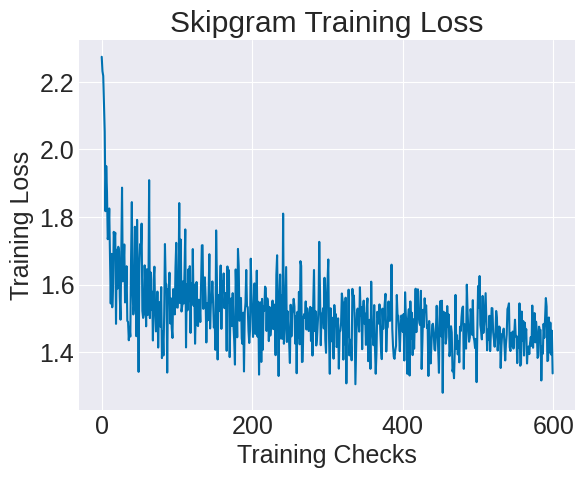

In [31]:
test_net = Skipgram(input_feats_shape=(test_vocab_sz,), C = test_vocab_sz, embedding_dim=7)
test_net.compile(lr = 1e-1)

train_loss_hist = test_net.fit(
    test_targets,
    test_contexts,
    batch_size=38,
    epochs=600,
    linear_lr_decay=True
)

plt.plot(train_loss_hist)
plt.xlabel('Training Checks')
plt.ylabel('Training Loss')
plt.title('Skipgram Training Loss')
plt.show()

### 2d. Get word embedding vectors


Before performing the big training run on the IMDb dataset, we will want to be able to extract and save the learned word vectors to disk so that when you use the word vectors next week, you will not have to wait for your Skipgram network to be retrained!

In the `Skipgram` class, implement:

- the `get_word_embedding` method that allows us to get the embedding vector for a single word from the trained network.
- the `get_all_embeddings` method that allows us to get all word embedding vectors from a list passed in to the trained network.
- the `get_bias` gets the hidden layer bias tensor.

Run the following code to test and save off the CS443 word embeddings.

#### Test `get_word_embedding`



In [32]:
print(f'The shape of one of your word vectors are {test_net.get_word_embedding(test_word2ind["colby"]).shape} and should be (7,)')
print(f'The word vector for "colby" looks like:\n{test_net.get_word_embedding(test_word2ind["colby"])}')

The shape of one of your word vectors are (7,) and should be (7,)
The word vector for "colby" looks like:
[ 1.1554784 -1.6611642 -0.8931825 -0.236669   0.928354   1.9099613
 -1.1407208]


#### Test `get_all_word_vectors`

In [33]:
word_vecs = test_net.get_all_embeddings()
print(f'Shape of word vectors: {word_vecs.shape} and should be (9, 7)')

Shape of word vectors: (9, 7) and should be (9, 7)


#### Test `get_bias`

In [34]:
bias = test_net.get_bias()
print(f'Shape of bias: {bias.shape} and should be (7,)')

Shape of bias: (7,) and should be (7,)


### 2e. Train your model on IMDb data

Set up and train a Skip-gram network on the IMDb movie review data:
1. Load in the IMDb data, form a corpus for the training set based on the 1st `10,000` reviews (*You are welcome to use the full `45,000` if you like, but `10,000` will take awhile and give us plenty of words*).
2. Train a Skipgram neural network on the corpus.
3. Print out your loss periodically during training. You should be getting around `6.4` loss by the end of training. There should be rapid improvement in the loss from an initial value of ~`11` early in training.
4. Create a plot showing the averaged training loss over recent mini-batches over the course of training. 

Use the default hyperparameters (including learning rate decay) except:
- Train for `10` epochs.
- Use a `5e-4` learning rate. 
- Use a batch size of `256`.
- Print out and average the training loss every `5000` or so mini-batches (*guideline*).

**Tips:**
- Training should take 1-2 hours on the GPU.
- Static graph compilation of the train and test steps is a good idea.
- If training on CoCalc, using JIT compilation is also a good idea to speed up training even more with `@tf.function(jit_compile=True)`

In [35]:
imdb_ds = WordLevelDataset()
target_words_int, context_words_int, vocab = imdb_ds.process(10000)

vocab_sz = len(vocab)
imdb_net = Skipgram(input_feats_shape=(vocab_sz,), C=vocab_sz)
imdb_net.compile(lr=5e-4)

Number of target words: 8400086
Number of context words: 8400086
---------------------------------------------------------------------------
Dense layer output(Output) shape: [1, 58260]
Dense layer output(Embedding) shape: [1, 96]
---------------------------------------------------------------------------


In [36]:
train_loss_hist = imdb_net.fit(
    target_words_int,
    context_words_int,
    batch_size=256,
    epochs=10,
    print_every=5000,
    linear_lr_decay=True,
    verbose=True
)

Mini-batch 5000/328120 - train loss 7.1510


Mini-batch 10000/328120 - train loss 6.8788


Mini-batch 15000/328120 - train loss 6.8103


Mini-batch 20000/328120 - train loss 6.7747


Mini-batch 25000/328120 - train loss 6.7414


...

Mini-batch 310000/328120 - train loss 6.4173


Mini-batch 315000/328120 - train loss 6.4088


Mini-batch 320000/328120 - train loss 6.4171


Mini-batch 325000/328120 - train loss 6.4158


Epoch 10/10 took 330.27s
Mini-batch 328120/328120 - train loss 6.4097
Finished training after 10 epochs!


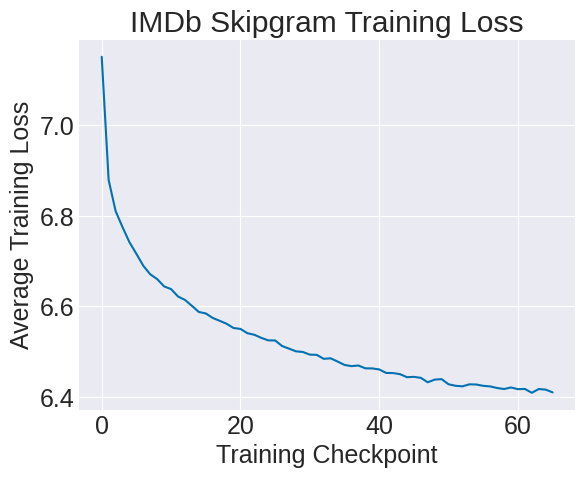

In [37]:
plt.plot(train_loss_hist)
plt.xlabel('Training Checkpoint')
plt.ylabel('Average Training Loss')
plt.title('IMDb Skipgram Training Loss')
plt.show()

### 2f. Save the word vectors and unique word strings for visualization

In the next notebook (`word_cloud.ipynb`), you will implement a self-organizing map (SOM) to visualize your IMDb word vectors. The number of reviews that you include in the training set and the hyperparameters used when training the Skip-gram network (e.g.  embedding dimension) will affect the quality of the visualization. 

Run the following code to export the word vectors and vocab to the `export` folder.

In [ ]:
imdb_net.save_embeddings()

Run the following cell to also export your IMDb corpus, vocabulary, and your word2ind and ind2word lookup tables.

*Adjust the name of the `WordLevelDataset` name as necessary.*

In [39]:
imdb_ds.save_vocab()
imdb_ds.save_corpus()
imdb_ds.save_word2ind_map()
imdb_ds.save_ind2word_map()